# Imports

In [ ]:
import numpy.polynomial.polynomial as polynomial
import matplotlib.pyplot as plt
import pandas as pd


# Shared

In [ ]:
# all data from the csv
raw_data = pd.read_csv("team01_ecommerce.csv")
print(raw_data)


     order_id  customer_id        date product_category  amount  \
0           1          103  2023-01-19            Books    6.80   
1           2          271  2023-01-18      Electronics   17.35   
2           3          107  2023-09-14         Clothing   34.89   
3           4           72  2023-03-19      Electronics   25.26   
4           5          189  2023-06-24      Electronics   23.90   
..        ...          ...         ...              ...     ...   
995       996           32  2023-03-01      Electronics   49.22   
996       997          158  2023-06-16             Home   63.35   
997       998          285  2023-07-21             Home   46.69   
998       999          286  2023-12-11      Electronics   31.49   
999      1000          144  2023-05-26            Books   37.03   

    payment_method shipping_state  returned  customer_age  
0       Debit Card             FL     False          26.0  
1           PayPal             CA     False          50.0  
2             C

# Data Structure and Types

In [ ]:
raw_data.shape

(1000, 9)

In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1000 non-null   int64  
 1   customer_id       1000 non-null   int64  
 2   date              1000 non-null   object 
 3   product_category  1000 non-null   object 
 4   amount            1000 non-null   float64
 5   payment_method    1000 non-null   object 
 6   shipping_state    971 non-null    object 
 7   returned          1000 non-null   bool   
 8   customer_age      953 non-null    float64
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 63.6+ KB


In [ ]:
raw_data.columns

Index(['order_id', 'customer_id', 'date', 'product_category', 'amount',
       'payment_method', 'shipping_state', 'returned', 'customer_age'],
      dtype='object')

# Data Cleaning

In [ ]:
# data is final, cleaned data
data = raw_data
# date strings to date objects
data['date'] = pd.to_datetime(data['date'])

print(data)

     order_id  customer_id       date product_category  amount payment_method  \
0           1          103 2023-01-19            Books    6.80     Debit Card   
1           2          271 2023-01-18      Electronics   17.35         PayPal   
2           3          107 2023-09-14         Clothing   34.89           Cash   
3           4           72 2023-03-19      Electronics   25.26    Credit Card   
4           5          189 2023-06-24      Electronics   23.90           Cash   
..        ...          ...        ...              ...     ...            ...   
995       996           32 2023-03-01      Electronics   49.22     Debit Card   
996       997          158 2023-06-16             Home   63.35         PayPal   
997       998          285 2023-07-21             Home   46.69         PayPal   
998       999          286 2023-12-11      Electronics   31.49    Credit Card   
999      1000          144 2023-05-26            Books   37.03           Cash   

    shipping_state  returne

In [ ]:
# rows that are missing one or more pieces of data
missing_rows = data[data.isna().any(axis=1)]
# number of missing pieces of data in each column
print(missing_rows.isna().sum(axis=0))


order_id             0
customer_id          0
date                 0
product_category     0
amount               0
payment_method       0
shipping_state      29
returned             0
customer_age        47
dtype: int64


As there are 1000 orders total, this means that `shipping_state` is missing 2.9% of its entries, and`customer_age` is missing 4.7% of its entries.

As `shipping_state` is categorical and not numerical, missing data can be treated as its own category.

For the purposes of this data challenge, missing values in `customer_age` can simply be ignored, as only the median is needed to answer the questions posed.

No inconsistencies or invalid data were found in the data set.

# Q1

Which product category has the highest return rate?


In [ ]:
# Calulate average return rate
return_rate = (
  data.groupby('product_category')['returned']
      .mean()
      .sort_values(ascending=False)
)

# convert to precentage
return_rate_percent = return_rate * 100
return_rate_percent

,returned
product_category,
Home,9.595960
Clothing,8.906883
Electronics,8.253968
Sports,5.882353
Books,5.806452


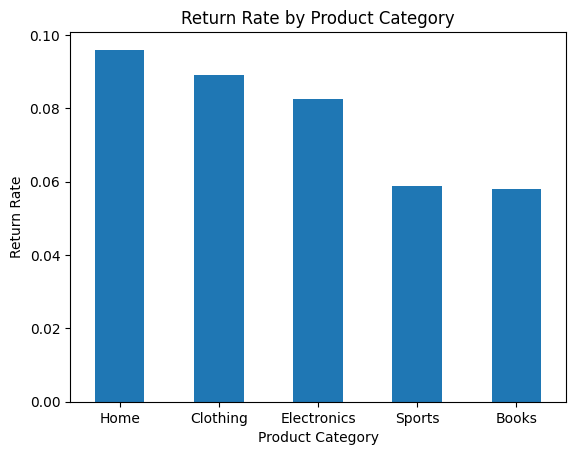

In [ ]:
# plot bar graph of return rate across categories
return_rate.plot(kind='bar')

# add labels
plt.title('Return Rate by Product Category')
plt.ylabel('Return Rate')
plt.xlabel('Product Category')
plt.xticks(rotation=0)

plt.show()

The category which has the highest return rate is Home, with a 9.60% return rate.

# Q2

What is the average order amount by payment method?

In [ ]:
# average order amount by payment method
avg_payment = (
data.groupby('payment_method')['amount']
    .mean()
    .sort_values(ascending=False)
)

avg_payment

,amount
payment_method,
Debit Card,43.581141
Credit Card,41.329961
Cash,40.143359
PayPal,37.922000


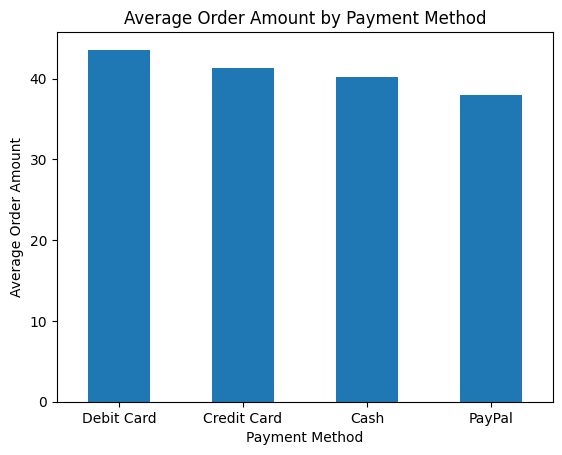

In [ ]:
# plot average order amounts across payment methods
avg_payment.plot(kind='bar')

# add labels
plt.title('Average Order Amount by Payment Method')
plt.ylabel('Average Order Amount')
plt.xlabel('Payment Method')
plt.xticks(rotation=0)

plt.show()

The average order amounts for each payment method are as follows:
|Method|Amount|
|--------|--------|
| Debit Card |	43.581141 |
| Credit Card |	41.329961 |
| Cash |	40.143359 |
| PayPal |	37.922000 |

# Q3
How does customer age affect purchase amount?

In [ ]:
# get data to plot, excluding missing ages
valid_data = data[data['customer_age'].isna()==False]
x_dat = valid_data['customer_age']
y_dat = valid_data['amount']


In [ ]:
# create a linear trend line from data
(trend_b, trend_m) = polynomial.polyfit(x_dat, y_dat, deg=1)
y_trend = trend_m*x_dat + trend_b


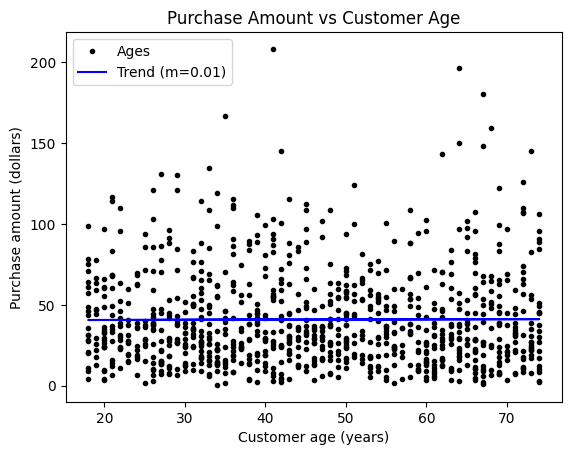

In [ ]:
# plot data points and trend line
plot = plt.figure()
plt.plot(x_dat, y_dat, "k .")
plt.plot(x_dat, y_trend, "b-,")

# add labels
plt.title("Purchase Amount vs Customer Age")
plt.xlabel("Customer age (years)")
plt.ylabel("Purchase amount (dollars)")
plt.legend(["Ages", f"Trend (m={round(trend_m, 3)})"])

plt.show()

In [ ]:
# reset
plt.clf()

<Figure size 640x480 with 0 Axes>

There does not appear to be any corelation between age and purchase amount.

# Q4
Which shipping state generates the most revenue?

In [ ]:
# sum revenue by state
state_revenue = (
data.groupby('shipping_state')['amount']
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head()

,amount
shipping_state,
NY,6837.74
TX,5812.70
IL,5762.31
OH,5726.31
PA,5518.54


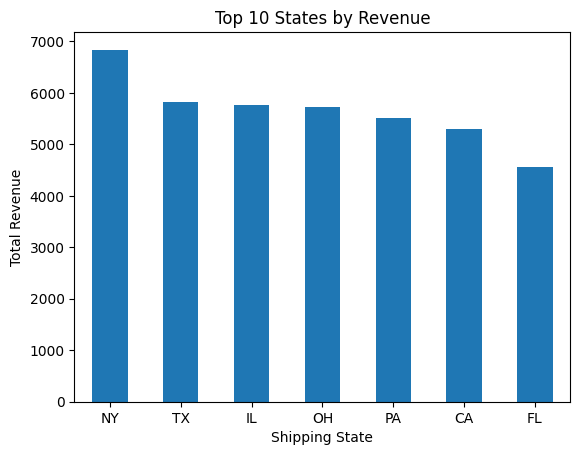

In [ ]:
# plot state revenue
state_revenue.head(10).plot(kind='bar')

# add labels
plt.title('Top 10 States by Revenue')
plt.ylabel('Total Revenue')
plt.xlabel('Shipping State')
plt.xticks(rotation=0)


plt.show()

The shipping state that generated the most revenue is NY (New York) which generated a total of 6837.74 in revenue.

# Q5
Is there a relationship between product category and customer age?

In [ ]:
# points to plot
x_dat = data['product_category']
y_dat = data['customer_age']

In [ ]:
# age data sorted by category
category_ages = data.groupby('product_category')['customer_age']

In [ ]:
# per-category age data (mean, median, stdev)
categories = data['product_category'].unique()
medians = category_ages.median()
stdevs = category_ages.std()

In [ ]:
# total age data
total_median = y_dat.median()
total_stdev = y_dat.std()

In [ ]:
# category age data
cat_stdev = medians.std()
cat_zscores = (medians-total_median)/total_stdev

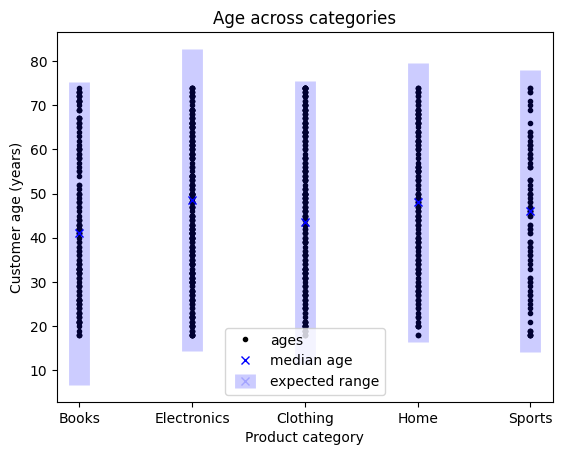

In [ ]:
# plot customer ages vs category
plot = plt.figure()
plt.plot(x_dat, y_dat, "k .")

# plot median, outlier boundary
plt.plot(categories, medians, "b x")
plt.errorbar(categories, medians, 2*stdevs, fmt="b x", alpha=0.2, elinewidth=15) # 2*stdev is boundary for outliers

# add labels
plt.title("Age across categories")
plt.xlabel("Product category")
plt.ylabel("Customer age (years)")
plt.legend(["ages", "median age", "expected range"])

plt.show()

In [ ]:
def beautify_category_data(cat_name, cat_data):
	"""
		formats `cat_name`, `cat_data` into a pretty string for printing outputs
	"""
	return (
		f"{(cat_name+":").ljust(14)}"			# category name, left-justified
		f"{"" if cat_data<0 else " "}"			# even out negative and positive numbers
		f"{str(round(cat_data, 2)).ljust(6)}"	# category data, left-justified
	)

In [ ]:
# output
print(f"z-scores of category medians:")
for cat in categories:
	print(f"\t{beautify_category_data(cat, cat_zscores[cat])}")

z-scores of category medians:
	Books:        -0.24 
	Electronics:  -0.09 
	Clothing:      0.21  
	Home:          0.18  
	Sports:        0.06  


As the z-scores of all the categories are well within normal ranges, there does not appear to be any meaningful relationship between product category and customer age?

# Q6
What percentage of customers make repeat purchases?

In [ ]:
# amount of orders from each customer
order_counts = data.groupby('customer_id')['customer_id'].count()

In [ ]:
# customers with more than 1 order
repeats = order_counts[order_counts>1]


In [ ]:
# count total and repeat customers
num_customers = order_counts.count()
num_repeats = repeats.count()

In [ ]:
# percentage of customers that are repeat customers
repeat_percentage = num_repeats/num_customers * 100

In [ ]:
# output
print(f"{num_repeats} repeat customers out of {num_customers} total customers")
print(f"{round(repeat_percentage, 1)}% repeat customers")


245 repeat customers out of 284 total customers
86.3% repeat customers


Thus, 86.3% of all customers have made more than one order.